## Amazon EU BSR Share 분석

In [23]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
import math
from datetime import date

In [2]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [3]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [7]:
# Top 20 --> Top 10 브랜드 데이터
sql = f"""
select * from wook.amz_eu_bsr_shr_daily_acc
where bsr_date >= '2023-01-01' and bsr_rank_range='Top 50'
"""

df = bqclient.query(sql).to_dataframe()

In [9]:
print(df)

        country   bsr_ctgry        asin  rank    bsr_date      brand  \
0            ES  mattresses  B0CTN2JPS7    39  2024-12-27  DESCANSIN   
1            BE  Mattresses  B084C241FW     4  2024-02-16  ORMISSIMO   
2            SE  Mattresses  B0CSK27R28    47  2024-12-17     Others   
3            UK  Mattresses  B0751K49SZ    14  2024-11-07     Others   
4            FR    Mattress  B0BQMWJ7PD    24  2025-05-11     IZTOSS   
...         ...         ...         ...   ...         ...        ...   
3381263      DE      Chairs  B0C9TKXWS4     4  2024-12-01    CASARIA   
3381264      DE      Chairs  B01BLC0WUI    36  2025-03-04     Others   
3381265      DE      Chairs  B098R61NB9    16  2023-06-30     Others   
3381266      DE      Chairs  B0DJGZ1DTL    36  2025-04-01     Others   
3381267      DE      Chairs  B0002DF7MQ    48  2024-08-13     Others   

                        brand_raw  \
0                       DESCANSIN   
1                       ORMISSIMO   
2                       

## 1.ZINUS BSR 점유률

In [17]:
df_2025 = df[df['yr_month'] >= '25-01'].copy()

In [19]:
print(df_2025)

        country   bsr_ctgry        asin  rank    bsr_date      brand  \
2            SE  Mattresses  B0CKZ8T9NS    37  2025-09-02        FDM   
10           UK  Mattresses  B0CJ2873MV    18  2025-01-13     TEQSLI   
11           DE  Mattresses  B0D14M2G6K    33  2025-03-09  VESGANTTI   
14           DE  Mattresses  B07PVJR392    44  2025-04-15        BMM   
16           BE  Mattresses  B0CKZ8XGP9    23  2025-06-22         DM   
...         ...         ...         ...   ...         ...        ...   
3377708      DE      Chairs  B0DG8Q59DV    16  2025-04-26    TECTAKE   
3377709      DE      Chairs  B0CGDDSYHQ    27  2025-01-12     Others   
3377710      DE      Chairs  B0D8L9NKH2    23  2025-02-01     HOMCOM   
3377712      DE      Chairs  B0CW9SSCXF     7  2025-04-11    TECTAKE   
3377717      DE      Chairs  B0F445WKD8    14  2025-05-26     KESSER   

         brand_raw                                              title  \
2              FDM  FDM Select MAX Mattress 140 x 200 cm, Foam

In [23]:
# 1) 전체 row 수
weekly_total = (
    df_2025.groupby(['country', 'bsr_ctgry', 'yr_week'])
    .size()
    .reset_index(name='total_count')
)

# 2) ZINUS row 수
weekly_zinus = (
    df_2025[df_2025['brand'].str.upper() == 'ZINUS']  # 대소문자 통일
    .groupby(['country', 'bsr_ctgry', 'yr_week'])
    .size()
    .reset_index(name='zinus_count')
)

# 3) 병합
weekly_share = weekly_total.merge(
    weekly_zinus, on=['country', 'bsr_ctgry', 'yr_week'], how='left'
)

# 4) NaN → 0 채우기
weekly_share['zinus_count'] = weekly_share['zinus_count'].fillna(0)

# 5) 점유율 계산
weekly_share['zinus_share'] = weekly_share['zinus_count'] / weekly_share['total_count']

print(weekly_share.head())

  country   bsr_ctgry  yr_week  total_count  zinus_count  zinus_share
0      BE  Bed Frames  Y25 W01          350          2.0     0.005714
1      BE  Bed Frames  Y25 W02          350          3.0     0.008571
2      BE  Bed Frames  Y25 W03          350          4.0     0.011429
3      BE  Bed Frames  Y25 W04          350          3.0     0.008571
4      BE  Bed Frames  Y25 W05          350          2.0     0.005714


In [27]:
# country별, bsr_ctgry별 ZINUS 점유율 평균
avg_share = (
    weekly_share.groupby(['country', 'bsr_ctgry'])['zinus_share']
    .mean()
    .reset_index()
    .rename(columns={'zinus_share': 'avg_zinus_share'})
)

print(avg_share)

   country             bsr_ctgry  avg_zinus_share
0       BE            Bed Frames         0.004643
1       BE  Beds, Frames & Bases         0.003857
2       BE                Chairs         0.000000
3       BE                 Desks         0.000000
4       BE            Mattresses         0.000214
..     ...                   ...              ...
66      UK                 Desks         0.000000
67      UK         Dining Tables         0.002143
68      UK      Mattress Toppers         0.004427
69      UK            Mattresses         0.032637
70      UK       Sofas & Couches         0.000143

[71 rows x 3 columns]


In [29]:
avg_share.to_csv('avg_zinus_share_0930.csv')

## 2. 전체 기간 : 2023년 ~ 평균 BSR 점유율

In [12]:
df1 = df.copy()

In [14]:
# 1) 전체 row 수
weekly_total = (
    df1.groupby(['country', 'bsr_ctgry', 'yr_week'])
    .size()
    .reset_index(name='total_count')
)

# 2) ZINUS row 수
weekly_zinus = (
    df1[df1['brand'].str.upper() == 'ZINUS']  # 대소문자 통일
    .groupby(['country', 'bsr_ctgry', 'yr_week'])
    .size()
    .reset_index(name='zinus_count')
)

# 3) 병합
weekly_share = weekly_total.merge(
    weekly_zinus, on=['country', 'bsr_ctgry', 'yr_week'], how='left'
)

# 4) NaN → 0 채우기
weekly_share['zinus_count'] = weekly_share['zinus_count'].fillna(0)

# 5) 점유율 계산
weekly_share['zinus_share'] = weekly_share['zinus_count'] / weekly_share['total_count']
print(weekly_share.head())


  country   bsr_ctgry  yr_week  total_count  zinus_count  zinus_share
0      BE  Bed Frames  Y23 W23          150          1.0     0.006667
1      BE  Bed Frames  Y23 W24          350          3.0     0.008571
2      BE  Bed Frames  Y23 W25          350          3.0     0.008571
3      BE  Bed Frames  Y23 W26          350          5.0     0.014286
4      BE  Bed Frames  Y23 W27          350          3.0     0.008571


In [42]:
# country별, bsr_ctgry별 ZINUS 점유율 평균
avg_share = (
    weekly_share.groupby(['country', 'bsr_ctgry'])['zinus_share']
    .mean()
    .reset_index()
    .rename(columns={'zinus_share': 'avg_zinus_share'})
)

print(avg_share)

   country             bsr_ctgry  avg_zinus_share
0       BE            Bed Frames         0.019542
1       BE  Beds, Frames & Bases         0.014473
2       BE                Chairs         0.000000
3       BE                 Desks         0.001124
4       BE            Mattresses         0.007378
..     ...                   ...              ...
66      UK                 Desks         0.003348
67      UK         Dining Tables         0.006437
68      UK      Mattress Toppers         0.001230
69      UK            Mattresses         0.017648
70      UK       Sofas & Couches         0.007497

[71 rows x 3 columns]


In [44]:
avg_share.to_csv('avg_zinus_share_all_0930.csv')

### 주별 지누스 점유율 Heatmap

In [11]:
df1 = df.copy()

# ✅ brand 컬럼 대문자 변환
df1['brand'] = df1['brand'].str.upper()

# ✅ groupby 단위: country, bsr_ctgry, yr_week
# 전체 row 수
weekly_total = (
    df1.groupby(['country', 'bsr_ctgry', 'yr_week'])
    .size()
    .reset_index(name='total_count')
)

# ZINUS row 수
weekly_zinus = (
    df1[df1['brand'] == 'ZINUS']
    .groupby(['country', 'bsr_ctgry', 'yr_week'])
    .size()
    .reset_index(name='zinus_count')
)

# ✅ 병합 후 점유율 계산
result = pd.merge(
    weekly_total, weekly_zinus,
    on=['country', 'bsr_ctgry', 'yr_week'],
    how='left'
)

# 결측치는 0으로 처리
result['zinus_count'] = result['zinus_count'].fillna(0)

# 점유율 계산
result['zinus_share'] = result['zinus_count'] / result['total_count']

# 보기 좋게 정렬
result = result.sort_values(['country', 'bsr_ctgry', 'yr_week']).reset_index(drop=True)

# 결과 확인
print(result.head(20))


   country   bsr_ctgry  yr_week  total_count  zinus_count  zinus_share
0       BE  Bed Frames  Y23 W23          150          1.0     0.006667
1       BE  Bed Frames  Y23 W24          350          3.0     0.008571
2       BE  Bed Frames  Y23 W25          350          3.0     0.008571
3       BE  Bed Frames  Y23 W26          350          5.0     0.014286
4       BE  Bed Frames  Y23 W27          350          3.0     0.008571
5       BE  Bed Frames  Y23 W28          350          0.0     0.000000
6       BE  Bed Frames  Y23 W29          350          2.0     0.005714
7       BE  Bed Frames  Y23 W30          350          3.0     0.008571
8       BE  Bed Frames  Y23 W31          350          7.0     0.020000
9       BE  Bed Frames  Y23 W32          350         11.0     0.031429
10      BE  Bed Frames  Y23 W33          350          4.0     0.011429
11      BE  Bed Frames  Y23 W34          350         15.0     0.042857
12      BE  Bed Frames  Y23 W35          350         33.0     0.094286
13    

In [13]:
avg_share = (
    result.groupby(['country', 'bsr_ctgry'], as_index=False)['zinus_share']
          .mean()
          .rename(columns={'zinus_share': 'avg_zinus_share'})
)

print(avg_share)
avg_share.to_csv('temp0002_0925.csv')

   country             bsr_ctgry  avg_zinus_share
0       BE            Bed Frames         0.017743
1       BE  Beds, Frames & Bases         0.012963
2       BE                Chairs         0.000000
3       BE                 Desks         0.001133
4       BE            Mattresses         0.007439
..     ...                   ...              ...
66      UK                 Desks         0.003372
67      UK         Dining Tables         0.006482
68      UK      Mattress Toppers         0.001254
69      UK            Mattresses         0.017468
70      UK       Sofas & Couches         0.007549

[71 rows x 3 columns]


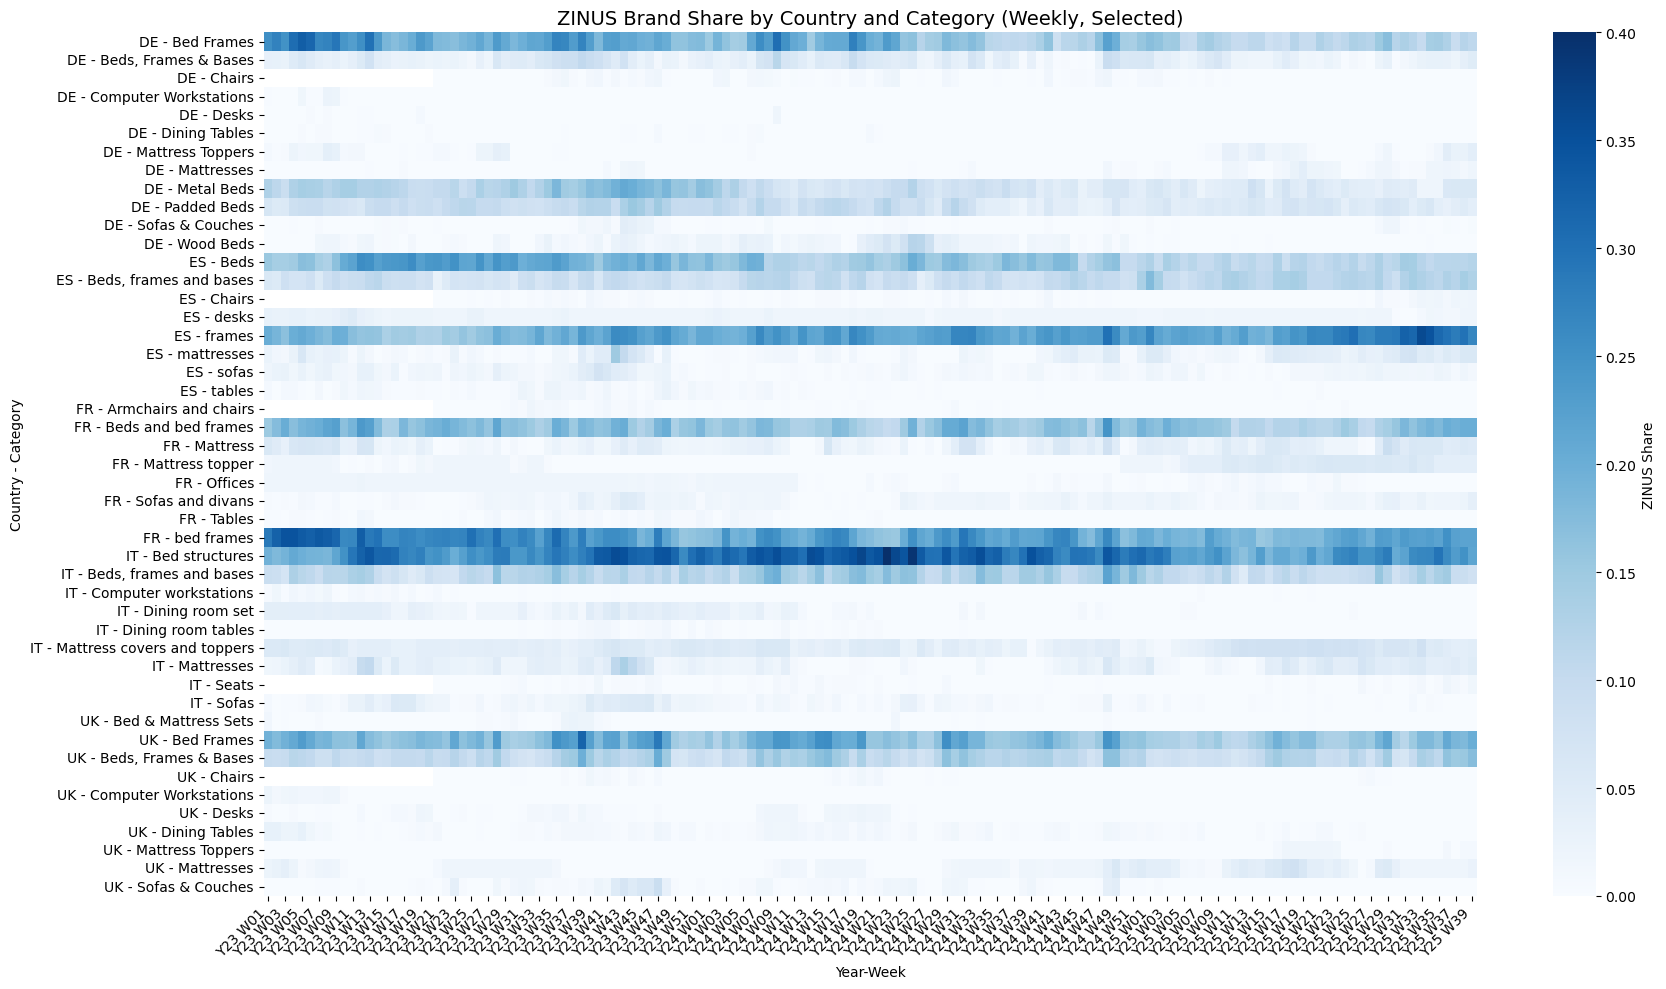

In [15]:

# ✅ 대상 국가만 필터링
target_countries = ["UK", "IT", "FR", "ES", "DE"]
filtered = result[result['country'].isin(target_countries)].copy()

# ✅ 제외할 국가-카테고리 정의
exclude_pairs = [
    #("UK", "Bed Frames"),
    ("IT", "Beds"),
    #("IT", "Bed structures"),
    ("FR", "Beds"),
    #("FR", "bed frames"),
    ("ES", "slatted bed bases"),
    ("ES", "Beds, structures and bases"),
    ("ES", "bed bases"),
    ("DE", "Slatted Divan Bases & Foundations")
]

# ✅ 제외 조건 적용
for c, cat in exclude_pairs:
    filtered = filtered[~((filtered['country'] == c) & (filtered['bsr_ctgry'] == cat))]

# ✅ Pivot 테이블 생성
pivot_table = filtered.pivot_table(
    index=['country', 'bsr_ctgry'],
    columns='yr_week',
    values='zinus_share',
    aggfunc='mean'
)

# 보기 좋게 인덱스 정리
pivot_table.index = [f"{c} - {cat}" for c, cat in pivot_table.index]

# ✅ 히트맵 그리기
plt.figure(figsize=(18, 10))
sns.heatmap(
    pivot_table,
    cmap="Blues",
    annot=False,
    cbar_kws={'label': 'ZINUS Share'}
)

plt.title("ZINUS Brand Share by Country and Category (Weekly, Selected)", fontsize=14)
plt.xlabel("Year-Week")
plt.ylabel("Country - Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

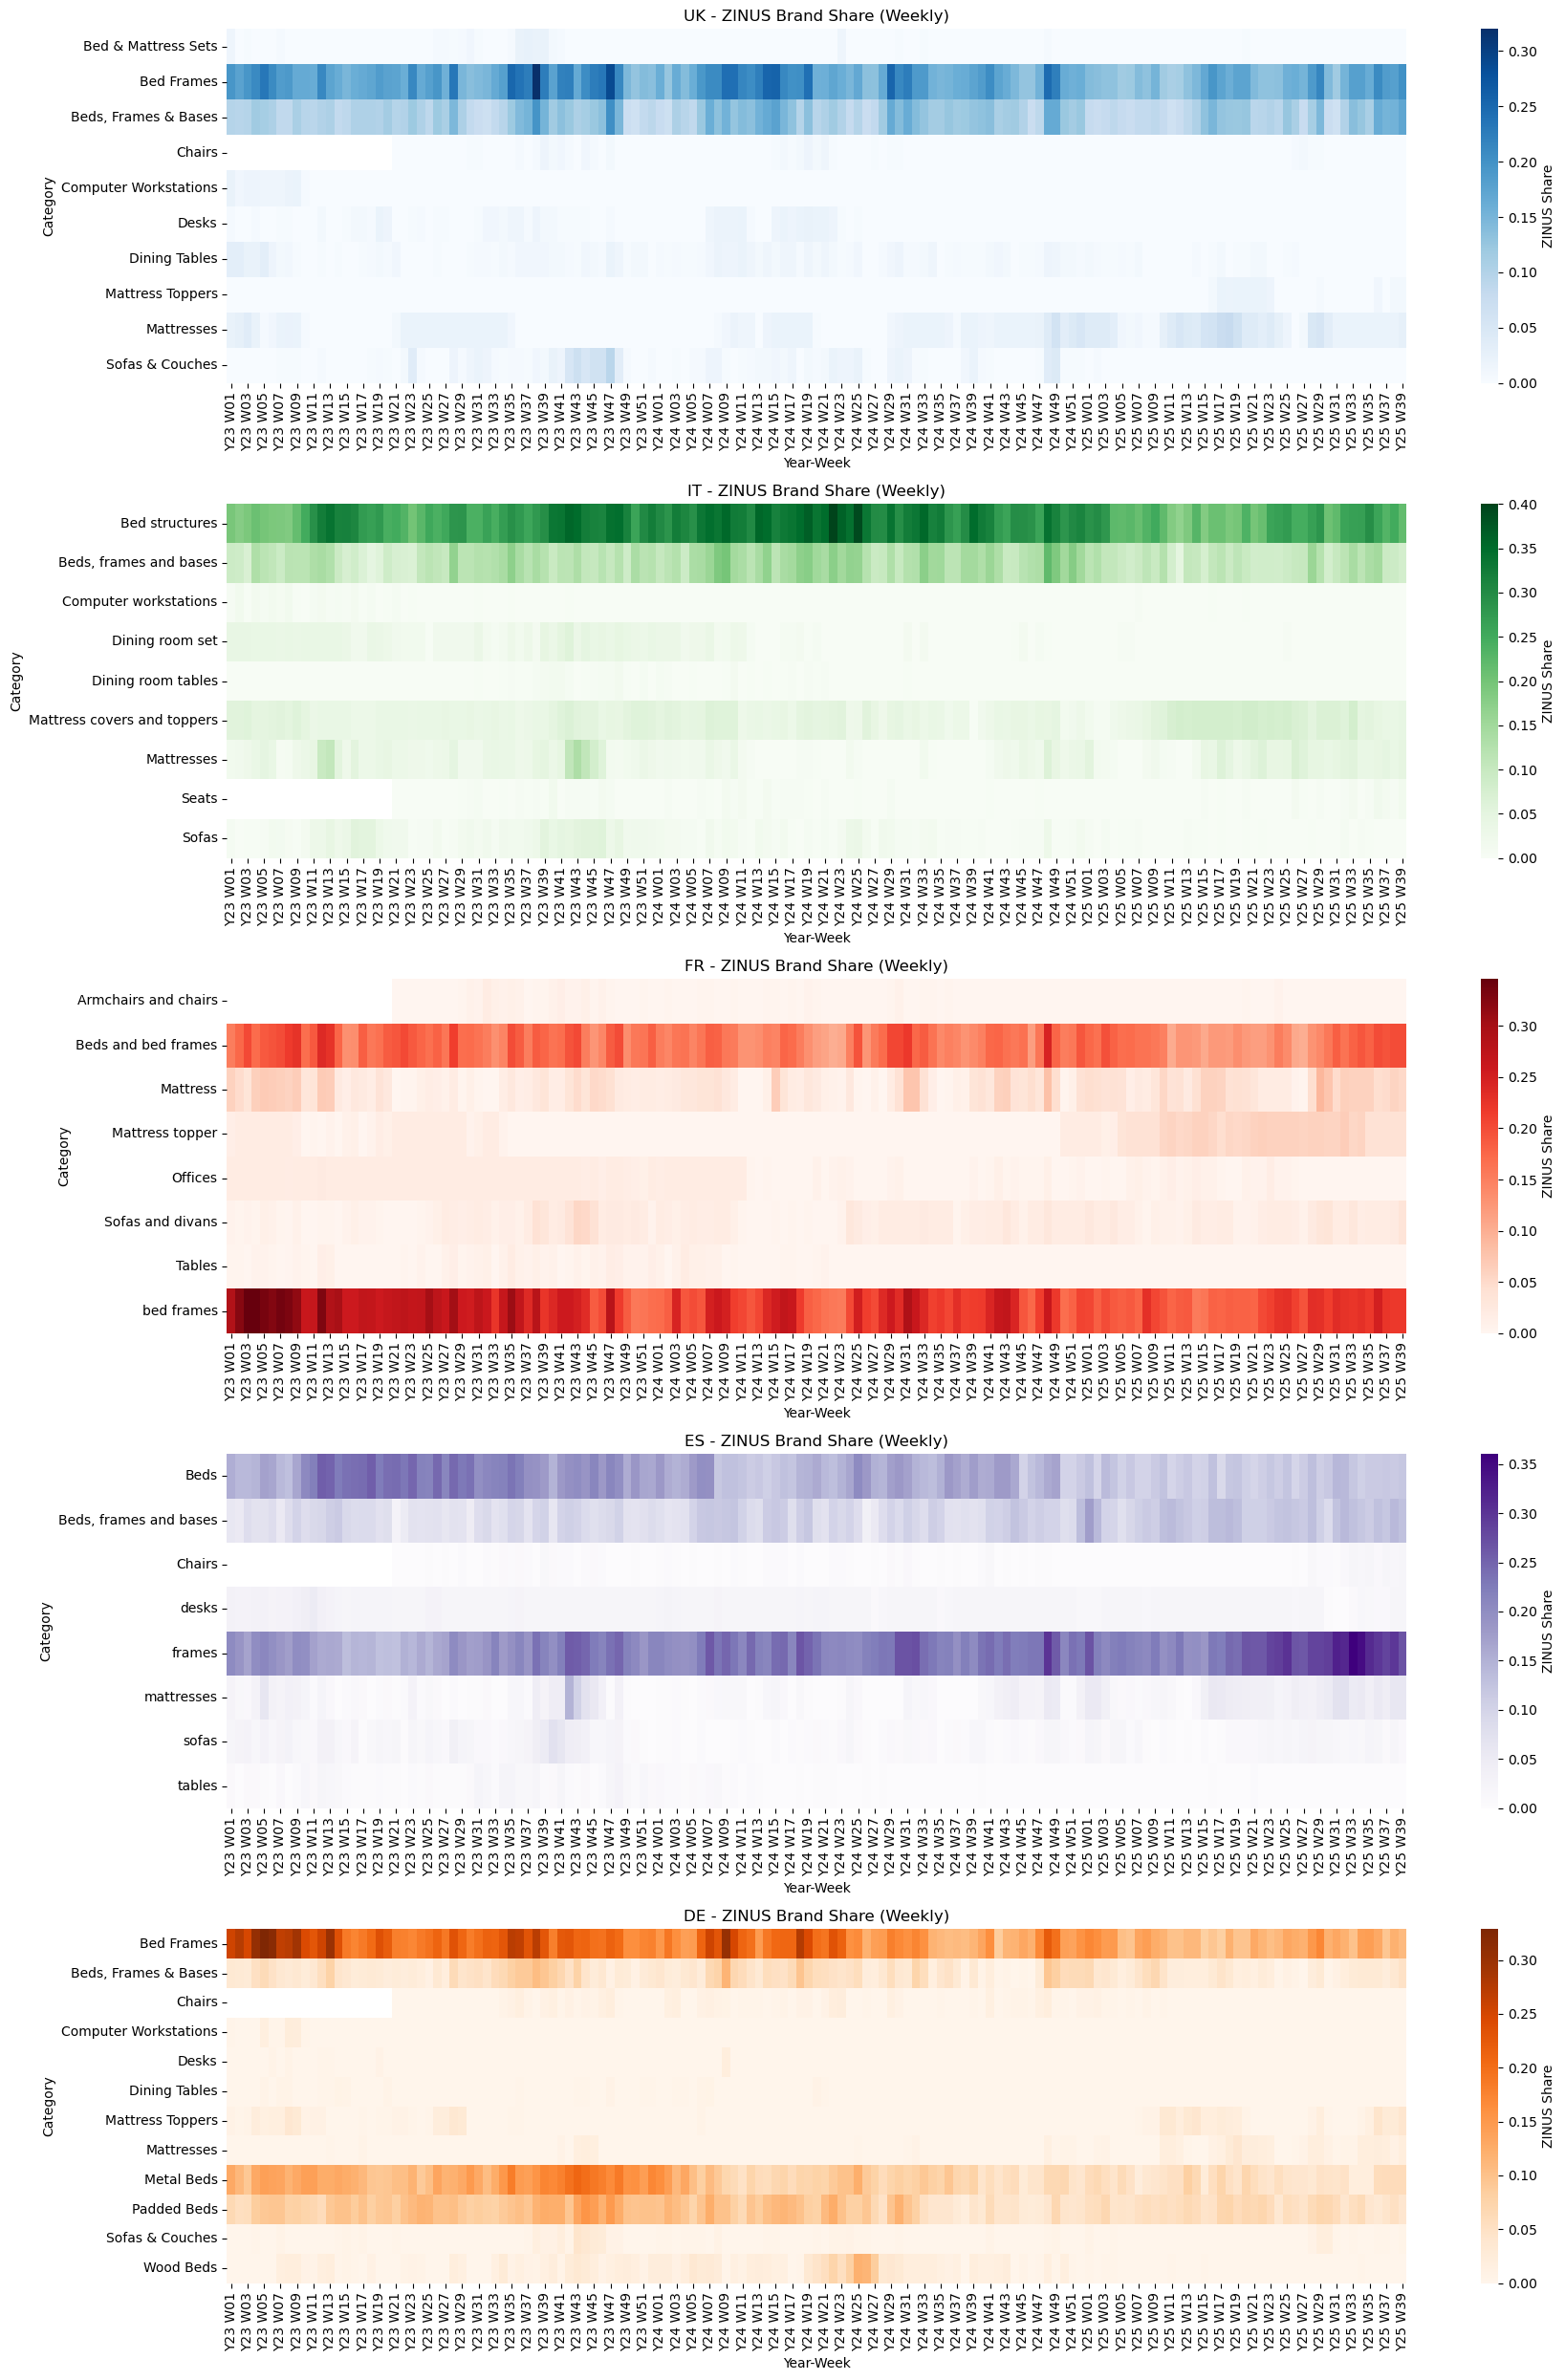

In [17]:

# ✅ 대상 국가
target_countries = ["UK", "IT", "FR", "ES", "DE"]

# ✅ 국가별로 다른 컬러맵 지정
cmaps = {
    "UK": "Blues",
    "IT": "Greens",
    "FR": "Reds",
    "ES": "Purples",
    "DE": "Oranges"
}

# ✅ subplot 생성
fig, axes = plt.subplots(len(target_countries), 1, figsize=(18, 5*len(target_countries)))

for ax, country in zip(axes, target_countries):
    data_cty = filtered[filtered['country'] == country]
    pivot_cty = data_cty.pivot_table(
        index='bsr_ctgry',
        columns='yr_week',
        values='zinus_share',
        aggfunc='mean'
    )

    sns.heatmap(
        pivot_cty,
        cmap=cmaps[country],
        annot=False,
        cbar_kws={'label': 'ZINUS Share'},
        ax=ax
    )
    ax.set_title(f"{country} - ZINUS Brand Share (Weekly)", fontsize=12)
    ax.set_xlabel("Year-Week")
    ax.set_ylabel("Category")

plt.tight_layout()
plt.show()

## 3. Top 브랜드 점유울 추이

In [11]:
df1 = df.copy()
df1['brand'] = df1['brand'].astype(str).str.upper()

# === 1) 대상 국가/카테고리 필터 ===
allowed_pairs = {
    "UK": ["Beds, Frames & Bases", "Mattresses"],
    "IT": ["Beds, frames and bases", "Mattresses"],
    "FR": ["Beds and bed frames", "Mattress"],
    "ES": ["Beds, frames and bases", "mattresses"],
    "DE": ["Beds, Frames & Bases", "Mattresses"],
}
mask_list = [
    (df1['country'] == c) & (df1['bsr_ctgry'].isin(cats))
    for c, cats in allowed_pairs.items()
]
df2 = df1[np.logical_or.reduce(mask_list)].copy()

# === 2) 주차별 전체/브랜드별 카운트 ===
tot = (
    df2.groupby(['country', 'bsr_ctgry', 'yr_week'])
       .size()
       .reset_index(name='total_count')
)
by_brand = (
    df2.groupby(['country', 'bsr_ctgry', 'yr_week', 'brand'])
       .size()
       .reset_index(name='brand_count')
)

# === 3) 주차별 점유율 계산 ===
df_wk = by_brand.merge(tot, on=['country','bsr_ctgry','yr_week'], how='left')
df_wk['brand_share_weekly'] = df_wk['brand_count'] / df_wk['total_count']

print(df_wk)

      country             bsr_ctgry  yr_week  \
0          DE  Beds, Frames & Bases  Y23 W01   
1          DE  Beds, Frames & Bases  Y23 W01   
2          DE  Beds, Frames & Bases  Y23 W01   
3          DE  Beds, Frames & Bases  Y23 W01   
4          DE  Beds, Frames & Bases  Y23 W01   
...       ...                   ...      ...   
22824      UK            Mattresses  Y25 W40   
22825      UK            Mattresses  Y25 W40   
22826      UK            Mattresses  Y25 W40   
22827      UK            Mattresses  Y25 W40   
22828      UK            Mattresses  Y25 W40   

                                       brand  brand_count  total_count  \
0                                  AGUA NOVA           14          350   
1                                 BETTEN-ABC           36          350   
2                                    BLUPALU            7          350   
3                                      COEMO            8          350   
4                                   DREAMZIE         

In [15]:
# === 4) country × bsr_ctgry × brand 단위로 집계
# (가중 평균 = sum(brand_count) / sum(total_count))
agg = (
    df_wk.groupby(['country','bsr_ctgry','brand'], as_index=False)
      .agg(
          brand_count_sum=('brand_count','sum'),
          total_count_sum=('total_count','sum')
      )
)
agg['brand_share'] = agg['brand_count_sum'] / agg['total_count_sum']

# 최종 프레임: country, bsr_ctgry, brand별 BSR 점유율
brand_share_ccb = agg[['country','bsr_ctgry','brand','brand_share']].copy()

# 필요 시 정렬 예시 (점유율 내림차순)
brand_share_ccb = brand_share_ccb.sort_values(
    ['country','bsr_ctgry','brand_share'],
    ascending=[True, True, False]
).reset_index(drop=True)

print(brand_share_ccb.head(20))

   country             bsr_ctgry              brand  brand_share
0       DE  Beds, Frames & Bases             OTHERS     0.395439
1       DE  Beds, Frames & Bases          YAHEETECH     0.098199
2       DE  Beds, Frames & Bases  SCHLUMMERPARADIES     0.087603
3       DE  Beds, Frames & Bases         BETTEN-ABC     0.067109
4       DE  Beds, Frames & Bases              ZINUS     0.040312
5       DE  Beds, Frames & Bases              COEMO     0.039904
6       DE  Beds, Frames & Bases           BRINLAWB     0.038176
7       DE  Beds, Frames & Bases             MURALO     0.034246
8       DE  Beds, Frames & Bases          AGUA NOVA     0.032205
9       DE  Beds, Frames & Bases           DREAMZIE     0.032007
10      DE  Beds, Frames & Bases        LILENO HOME     0.029912
11      DE  Beds, Frames & Bases            YOCREAT     0.028920
12      DE  Beds, Frames & Bases           SLEEPNEO     0.028507
13      DE  Beds, Frames & Bases             DICTAC     0.027593
14      DE  Beds, Frames 

In [27]:
uk_mattresses = brand_share_ccb.query("country == 'UK' and bsr_ctgry == 'Beds, Frames & Bases'")
uk_mattresses.sort_values('brand_share', ascending=False)

,country,bsr_ctgry,brand,brand_share
173,UK,"Beds, Frames & Bases",OTHERS,0.349229
174,UK,"Beds, Frames & Bases",YAHEETECH,0.212340
175,UK,"Beds, Frames & Bases",ZINUS,0.112688
176,UK,"Beds, Frames & Bases",BED CENTRE,0.045154
177,UK,"Beds, Frames & Bases",GENERIC,0.045059
178,UK,"Beds, Frames & Bases",YOCREAT,0.042564
179,UK,"Beds, Frames & Bases",HOME TREATS,0.034978
180,UK,"Beds, Frames & Bases","COMFOREST, BEDDING & UPHOLSTERY INNOVATION LEADER",0.030517
181,UK,"Beds, Frames & Bases",LUTOWN-TEEN,0.024974
182,UK,"Beds, Frames & Bases",JAY-BE,0.024333


In [52]:
uk_mattresses = sub.query("country == 'UK' and bsr_ctgry == 'Mattresses'")
uk_mattresses.sort_values('brand_share_weekly', ascending=False)

,country,bsr_ctgry,yr_week,brand,brand_count,total_count,brand_share_weekly,brand_upper,brand_compact,brand_up


In [54]:
print(sub['country'].unique())
print(sub['bsr_ctgry'].unique())

['UK']
['Beds, Frames & Bases']


## Top 10 브랜드 선별하기

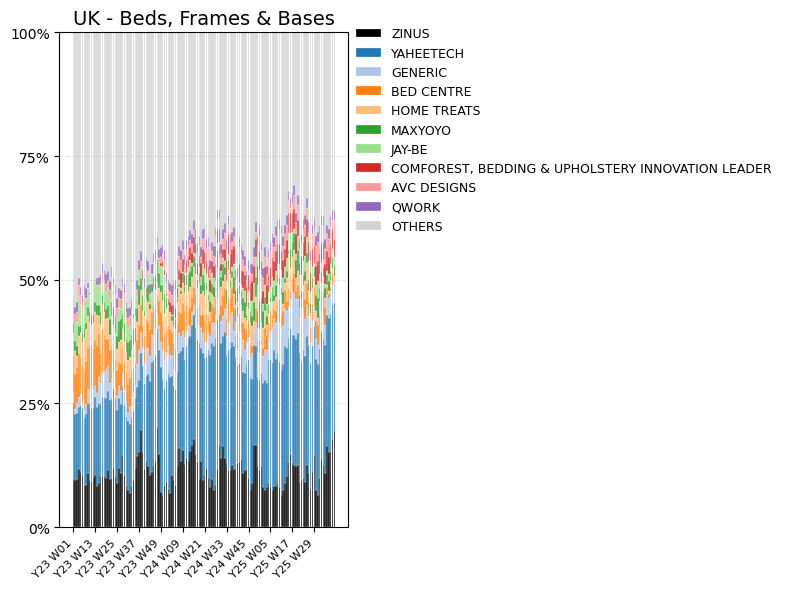

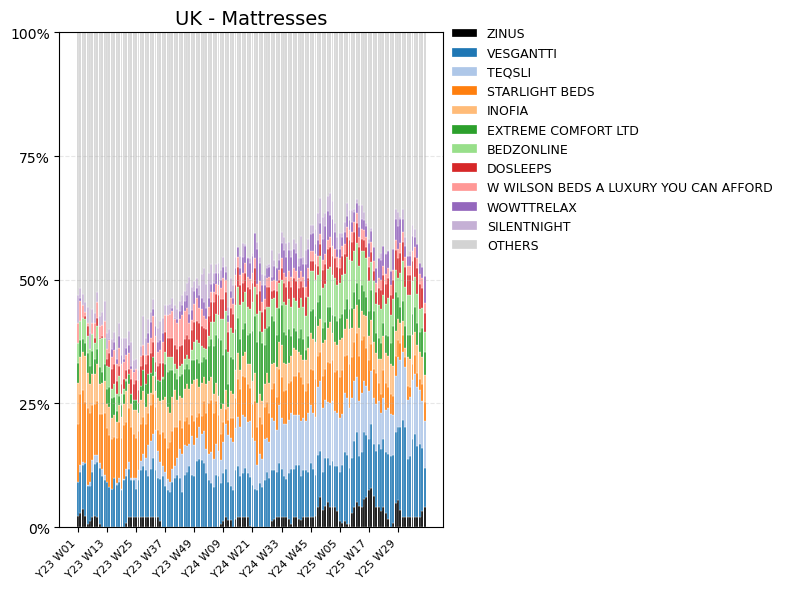

In [31]:

# ---------- 유틸 함수 ----------
def parse_yrweek(s):
    """'Y23 W01' -> (2023,1)"""
    m = re.search(r'Y(\d{2})\s*W(\d{2})', str(s))
    if m:
        return (2000+int(m.group(1)), int(m.group(2)))
    return (0,0)

def week_to_date(year, week):
    return date.fromisocalendar(year, week, 1)

# ---------- 파라미터 ----------
TOP_K = 10
ZINUS_UP = "ZINUS"

# X축 최대 라벨 개수(혼잡도 제어)
MAX_XTICKS = 12

# 정규화 모드: 'none' | 'original_total'
#  - 'none'            : 재정규화하지 않음(권장: 이미 brand_share_weekly가 비중이면 그대로 사용)
#  - 'original_total'  : Top10+OTHERS로 축소 후에도 "축소 전" 주차별 총합(보통 1)을 분모로 사용
NORMALIZE_MODE = 'none'

# ---------- 데이터 준비 ----------
df2 = df_wk.copy()

# country = UK만 추출
df_uk = df2[df2['country']=="UK"].copy()
df_uk['brand_up'] = df_uk['brand'].str.upper()

# 카테고리별 반복
for cat in sorted(df_uk['bsr_ctgry'].unique()):
    sub = df_uk[df_uk['bsr_ctgry']==cat].copy()

    # === 0) 대표명 매핑(대문자 -> 원래 표기), ZINUS는 'ZINUS'로 통일 ===
    mask_not_others = sub['brand_up']!='OTHERS'
    rep_names = (sub[mask_not_others]
                 .drop_duplicates('brand_up')
                 .set_index('brand_up')['brand']
                 .to_dict())
    rep_names[ZINUS_UP] = 'ZINUS'

    # === 1) Top10 선정(원본 합계 기준, OTHERS 제외) → 이 순서를 "끝까지" 유지 ===
    agg = (sub[mask_not_others]
           .groupby('brand_up', as_index=False)['brand_share_weekly']
           .sum()
           .sort_values('brand_share_weekly', ascending=False))

    top10_up = agg['brand_up'].head(TOP_K).tolist()
    # ZINUS가 존재하는데 Top10에 없다면 포함(요구사항에 맞게)
    if (ZINUS_UP not in top10_up) and (sub['brand_up'].eq(ZINUS_UP).any()):
        top10_up.append(ZINUS_UP)

    # === 2) brand_compact 생성: Top10은 개별 유지, 그 외는 OTHERS ===
    keep_set = set(top10_up)
    def to_compact(row):
        bu = row['brand_up']
        if bu == 'OTHERS':
            return 'OTHERS'
        if bu in keep_set:
            return rep_names.get(bu, row['brand'])
        return 'OTHERS'
    sub['brand_compact'] = sub.apply(to_compact, axis=1)

    # === 3) 주차 정렬: 시간순 정렬은 parse_yrweek로, 라벨은 원문 그대로 사용 ===
    weeks = sorted(sub['yr_week'].unique(), key=parse_yrweek)

    # === 4) 축소 전 주차별 총합(원래 분모) 계산: 'original_total' 정규화 시 사용 ===
    if len(weeks) > 0:
        weekly_total_original = (sub.groupby('yr_week')['brand_share_weekly']
                                   .sum()
                                   .reindex(weeks)
                                   .fillna(0.0))
    else:
        weekly_total_original = pd.Series(dtype=float)

    # === 5) pivot: 주차 × brand_compact (Top10+OTHERS만) ===
    pivot = (sub.groupby(['yr_week','brand_compact'])['brand_share_weekly']
               .sum().unstack(fill_value=0.0)
               .reindex(weeks).fillna(0.0))

    # === 6) 컬럼 순서: [ZINUS] + Top10(표시명 변환) + [OTHERS]
    #     - Top10 순서는 "선정 당시 순서(top10_up)"를 그대로 유지
    #     - 단, 'ZINUS'는 맨 앞으로, 'OTHERS'는 맨 뒤로 고정
    top10_display = [rep_names.get(bu, bu) for bu in top10_up if bu not in (ZINUS_UP, 'OTHERS')]
    cols_available = set(pivot.columns)
    ordered_cols = []
    if 'ZINUS' in cols_available:
        ordered_cols.append('ZINUS')
    ordered_cols.extend([c for c in top10_display if c in cols_available])
    if 'OTHERS' in cols_available:
        ordered_cols.append('OTHERS')
    # 혹시 누락된 컬럼이 있다면(데이터 특성상 드물지만) 뒤에 붙임
    ordered_cols.extend([c for c in pivot.columns if c not in ordered_cols])
    pivot = pivot.reindex(columns=ordered_cols)

    # === 7) 재정규화: 기본은 'none'(권장). 필요 시 'original_total' 선택 ===
    if NORMALIZE_MODE == 'original_total' and len(weekly_total_original) > 0:
        # 축소 후에도 "축소 전 분모"로 나눔 → 순위 왜곡 최소화
        pivot = pivot.div(weekly_total_original.replace(0, 1), axis=0)
    # NORMALIZE_MODE == 'none' 이면 재정규화하지 않음

    # === 8) 색상 매핑: ZINUS=black, OTHERS=lightgray, 나머지 팔레트 순환 ===
    #    (Top10 순서가 많아도 구분되도록 tab20 계열을 확장)
    def make_colors(n):
        cols = []
        for cm in (plt.cm.tab20, plt.cm.tab20b, plt.cm.tab20c):
            cols.extend([cm(i) for i in range(cm.N)])  # 각 20색 → 총 60색
        if n > len(cols):
            extra = n - len(cols)
            cols.extend([plt.cm.hsv(i / max(1, extra)) for i in range(extra)])
        return cols[:n]

    # ZINUS/OTHERS를 제외한 나머지(Top10 Display 순서)에 색 부여
    rest_for_colors = [c for c in ordered_cols if c not in ('ZINUS', 'OTHERS')]
    color_list = make_colors(len(rest_for_colors))
    cmap = {}
    if 'ZINUS' in pivot.columns: cmap['ZINUS'] = 'black'
    if 'OTHERS' in pivot.columns: cmap['OTHERS'] = 'lightgray'
    for j, br in enumerate(rest_for_colors):
        cmap[br] = color_list[j]

    # === 9) Plot ===
    fig, ax = plt.subplots(figsize=(8, 6))
    x = np.arange(len(pivot))
    bottom = np.zeros(len(pivot))
    for col in pivot.columns:
        ax.bar(
            x, pivot[col], bottom=bottom,
            label=col,                       # 라벨 자르지 않음
            color=cmap.get(col, None),
            edgecolor='white', linewidth=0.2 # 얇은 조각 가독성
        )
        bottom += pivot[col].values

    ax.set_title(f"UK - {cat}", fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Y축: 비율처럼 보이도록(필요 시 주석 처리 가능)
    ax.set_ylim(0, max(1.0, pivot.values.max()*1.05))
    ax.set_yticks([0, .25, .5, .75, 1])
    ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])

    # X축: yr_week 라벨 샘플링(원문 그대로)
    n = len(weeks)
    if n == 0:
        ax.set_xticks([])
    else:
        step = max(1, int(np.ceil(n / MAX_XTICKS)))
        tick_idx = np.arange(0, n, step)
        ax.set_xticks(tick_idx)
        ax.set_xticklabels([weeks[i] for i in tick_idx], rotation=45, ha='right', fontsize=8)

    # 범례: 바깥쪽
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))  # 중복 제거
    ax.legend(
        by_label.values(), by_label.keys(),
        loc='upper left', bbox_to_anchor=(1.01, 1.02),
        borderaxespad=0., fontsize=9, frameon=False,
        ncol=1 if len(by_label) < 20 else 2
    )

    plt.tight_layout()
    plt.show()


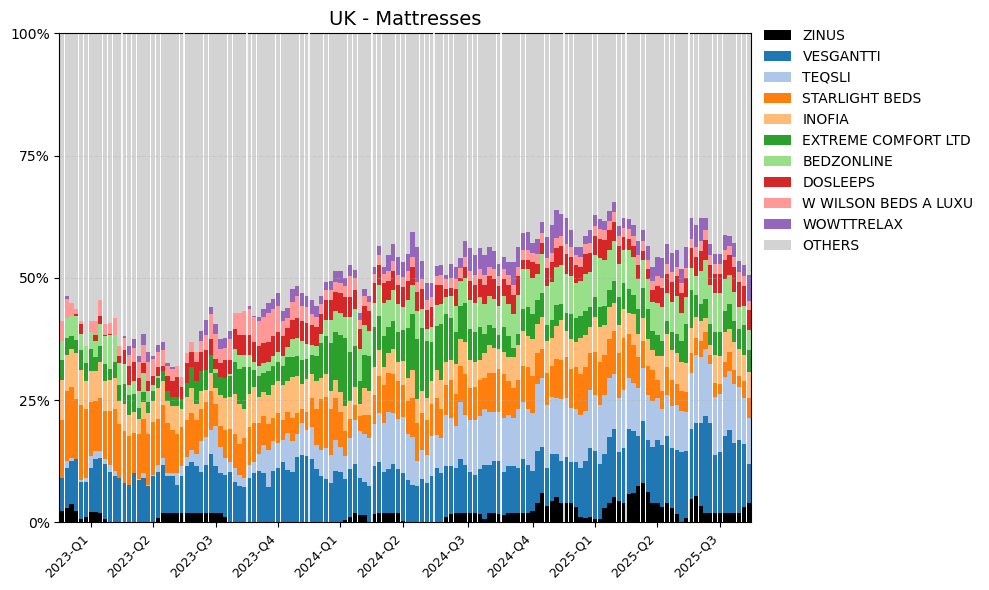

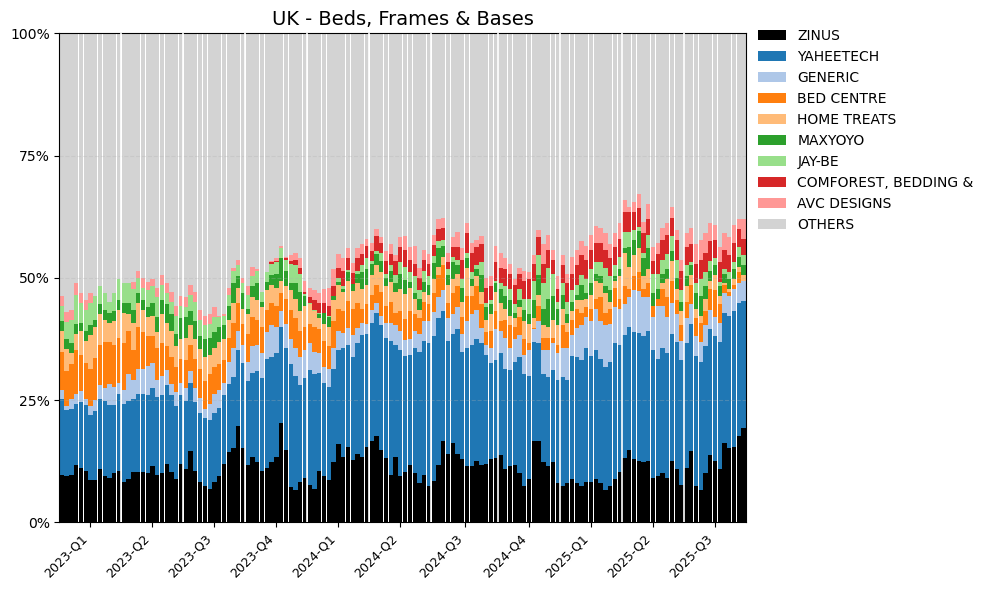

In [30]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import date

# ------------------------------------------------------------
# 0) 유틸 함수: 주차 파싱/정렬키, 분기 경계 계산
# ------------------------------------------------------------
def parse_yrweek(s: str):
    """
    'Y23 W01' -> (2023, 1)
    그 외 형식은 (0,0)
    """
    if pd.isna(s):
        return (0, 0)
    m = re.search(r'Y(\d{2})\s*W(\d{2})', str(s))
    if m:
        return (2000 + int(m.group(1)), int(m.group(2)))
    return (0, 0)

def week_to_iso_monday(year: int, week: int) -> date:
    """
    ISO 주차의 월요일 날짜 반환 (datetime.date)
    """
    # ISO week는 1~53, 요일 1=월요일
    week = max(1, min(int(week), 53))
    return date.fromisocalendar(int(year), week, 1)

def quarter_label_from_date(d: date) -> str:
    q = (d.month-1)//3 + 1
    return f"{d.year}-Q{q}"

def quarter_bounds_from_weeks(weeks_sorted):
    """
    weeks_sorted: ['Y23 W01','Y23 W02', ...] (정렬된 상태)
    리턴: [(start_idx, end_idx, 'YYYY-Qn'), ...]
      - start_idx/end_idx 는 인덱스 숫자 (포함 구간)
    """
    # 각 주에 대응하는 분기 라벨
    qlabels = []
    for w in weeks_sorted:
        y, wnum = parse_yrweek(w)
        if y == 0:
            qlabels.append("Unknown")
        else:
            d = week_to_iso_monday(y, wnum)
            qlabels.append(quarter_label_from_date(d))

    bounds = []
    if not qlabels:
        return bounds

    start = 0
    curr = qlabels[0]
    for i, q in enumerate(qlabels[1:], start=1):
        if q != curr:
            bounds.append((start, i-1, curr))
            start = i
            curr = q
    bounds.append((start, len(qlabels)-1, curr))
    return bounds

# ------------------------------------------------------------
# 1) 설정
# ------------------------------------------------------------
country = 'UK'
TOP_K = 10     # Top10 + ZINUS + OTHERS
ZINUS_NAME_UPPER = 'ZINUS'

# ------------------------------------------------------------
# 2) 원본 데이터 준비 (df_wk가 존재한다고 가정)
# ------------------------------------------------------------
df = df_wk.copy()

# 결측 brand_share_weekly 보정 (가능 시)
if 'brand_share_weekly' in df.columns:
    null_mask = df['brand_share_weekly'].isna()
    if null_mask.any():
        # brand_count / total_count 로 대체
        df.loc[null_mask, 'brand_share_weekly'] = (
            df.loc[null_mask, 'brand_count'] / df.loc[null_mask, 'total_count']
        )

# 소문자/대문자 혼용 대비
df['brand_upper'] = df['brand'].astype(str).str.upper()

# 대상 국가 필터
sub_country = df[df['country'] == country].copy()

if sub_country.empty:
    print(f"[WARN] {country} 데이터가 없습니다.")
else:
    # ✅ 카테고리 정렬: 'mattress' 포함 우선 + 나머지 알파벳순
    cats = list(sub_country['bsr_ctgry'].dropna().unique())
    cats = sorted(cats, key=lambda c: (0 if 'mattress' in str(c).lower() else 1, str(c).lower()))

    for cat in cats:
        sub = sub_country[sub_country['bsr_ctgry'] == cat].copy()
        if sub.empty:
            continue

        # --- 주차 정렬 ---
        weeks = sorted(sub['yr_week'].astype(str).unique(), key=parse_yrweek)

        # --- Top K 브랜드 선별 (기간 전체 합계 기준) ---
        #     ZINUS는 별도 보장 포함
        agg = (sub.groupby('brand', as_index=False)['brand_share_weekly']
                 .sum()
                 .sort_values('brand_share_weekly', ascending=False))
        top_list = agg['brand'].head(TOP_K).tolist()

        # ZINUS 보장 포함 (대소문자 무시)
        has_zinus = any(b.upper() == ZINUS_NAME_UPPER for b in top_list)
        if not has_zinus:
            # ZINUS가 데이터에 존재하면 포함
            if (sub['brand_upper'] == ZINUS_NAME_UPPER).any():
                # 맨 뒤에 추가
                top_list = list(dict.fromkeys(top_list + [ZINUS_NAME_UPPER]))  # 중복제거 보장

        # --- brand_compact 생성 (ZINUS / TopK / OTHERS) ---
        def to_compact(row):
            b = row['brand']
            bu = row['brand_upper']
            if bu == ZINUS_NAME_UPPER:
                return 'ZINUS'
            # top_list가 원 브랜드명과 대소문자 섞일 수 있으므로 비교 유연화
            if any(bu == t.upper() for t in top_list):
                # top_list 안에 있는 원래 표기 유지
                # (동일 브랜드라도 표기가 여러가지면 최초 표기 사용)
                for t in top_list:
                    if bu == t.upper():
                        return t
                return b
            return 'OTHERS'

        sub['brand_compact'] = sub.apply(to_compact, axis=1)

        # --- 주차 x brand_compact 합산 (brand_share_weekly의 합) ---
        weekly_compact = (sub.groupby(['yr_week', 'brand_compact'], as_index=False)
                            ['brand_share_weekly'].sum())

        # --- 피벗 (주차 인덱스, 브랜드 열) ---
        pivot = (weekly_compact
                 .pivot_table(index='yr_week', columns='brand_compact',
                              values='brand_share_weekly', aggfunc='sum')
                 .reindex(index=weeks)   # 주차 순서 유지
                 .fillna(0.0))

        # --- 필요한 열 보장 ---
        for req in ('ZINUS', 'OTHERS'):
            if req not in pivot.columns:
                pivot[req] = 0.0

        # --- 스택 순서 (ZINUS, 그 외(총합 내림차순), OTHERS) ---
        rest = [c for c in pivot.columns if c not in ('ZINUS', 'OTHERS')]
        rest_sorted = pivot[rest].sum(0).sort_values(ascending=False).index.tolist()
        pivot = pivot[['ZINUS', *rest_sorted, 'OTHERS']]

        # --- 100% 정규화 (안전장치) ---
        row_sum = pivot.sum(axis=1).replace(0, 1)
        pivot = pivot.div(row_sum, axis=0)

        # --- 색상 ---
        base_colors = plt.cm.tab20.colors
        color_map = {'ZINUS': 'black', 'OTHERS': 'lightgray'}
        for j, br in enumerate(rest_sorted):
            color_map[br] = base_colors[j % len(base_colors)]

        # --- Figure/Axis ---
        fig, ax = plt.subplots(figsize=(10, 6))
        x = np.arange(len(pivot))
        bottom = np.zeros(len(pivot))

        for col in pivot.columns:
            ax.bar(
                x, pivot[col].values, bottom=bottom, width=0.9,
                label=(col if len(str(col)) <= 20 else str(col)[:20]),
                color=color_map.get(col, None)
            )
            bottom += pivot[col].values

        # --- Y축 설정 ---
        ax.set_ylim(0, 1)
        ax.set_yticks([0, .25, .5, .75, 1.0])
        ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.set_xlim(-0.5, len(x) - 0.5)

        # ✅ 타이틀: 국가 + 카테고리
        ax.set_title(f"{country} - {cat}", fontsize=14)

        # --- X축: 분기 라벨 & 구분선 ---
        qbounds = quarter_bounds_from_weeks(weeks)
        if qbounds:
            xticks = [(s + e) / 2 for s, e, _ in qbounds]
            xlabels = [lbl for _, _, lbl in qbounds]
            ax.set_xticks(xticks)
            ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=9)
            # 분기 경계선 (마지막 구간 직전까지만)
            for s, e, _ in qbounds[:-1]:
                ax.axvline(e + 0.5, color='white', linewidth=1.2, zorder=3)
        else:
            # 주차 직접 표기(데이터가 적거나 포맷 이슈인 경우)
            ax.set_xticks(x)
            ax.set_xticklabels(pivot.index.tolist(), rotation=90, fontsize=8)

        # --- 범례 ---
        ax.legend(
            loc='upper left', bbox_to_anchor=(1.01, 1.02),
            borderaxespad=0., fontsize=10, frameon=False
        )

        plt.tight_layout()
        plt.show()


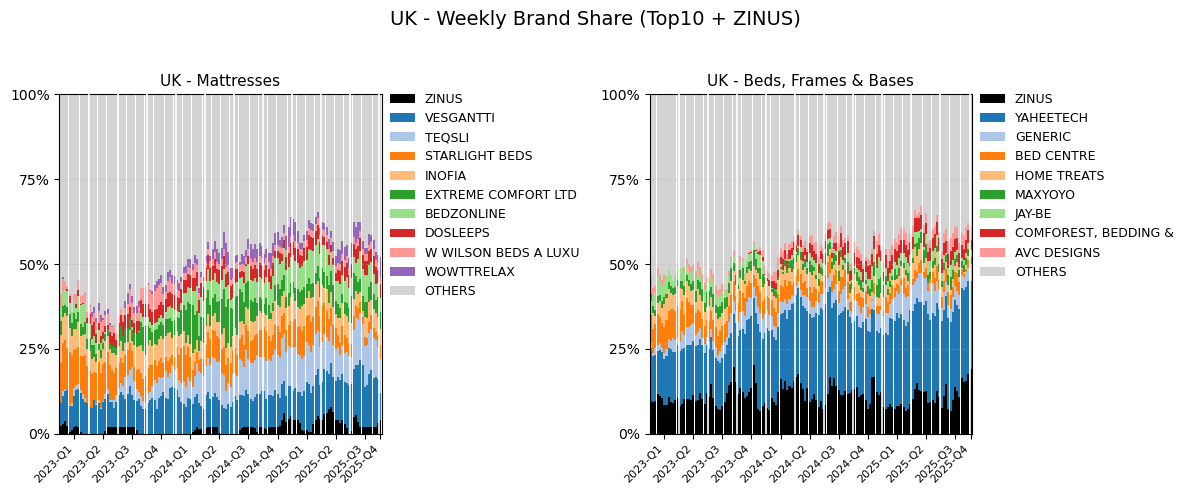

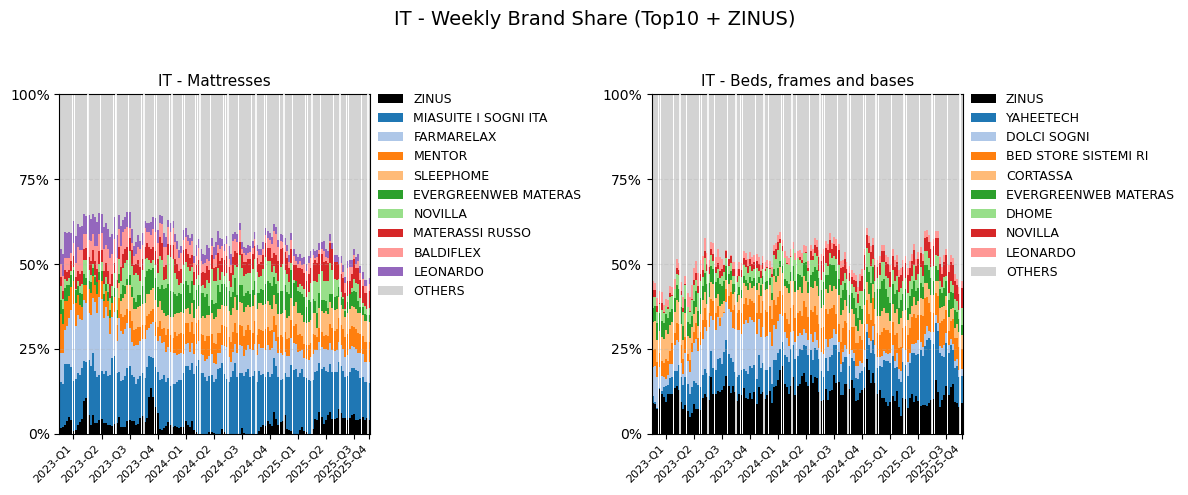

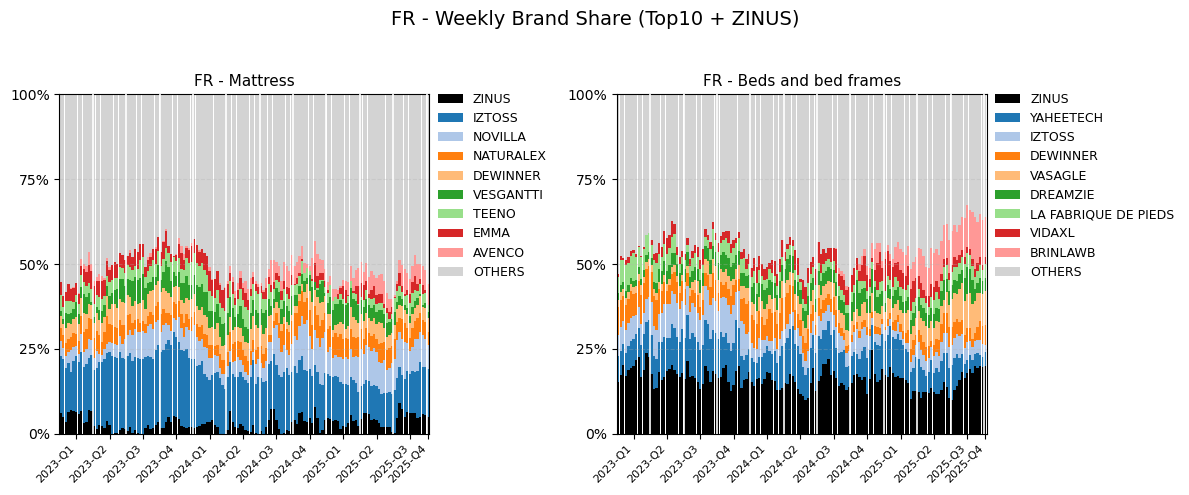

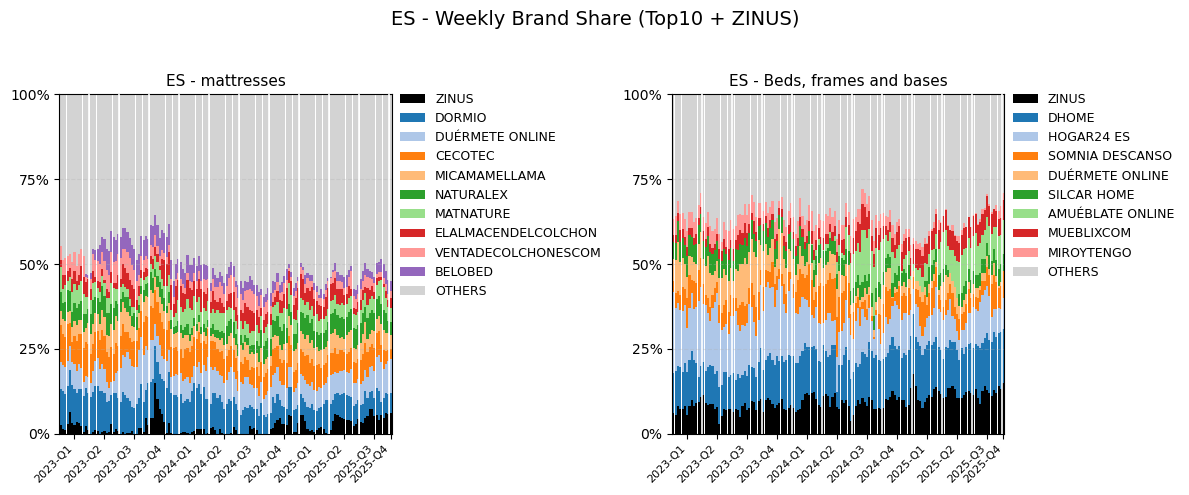

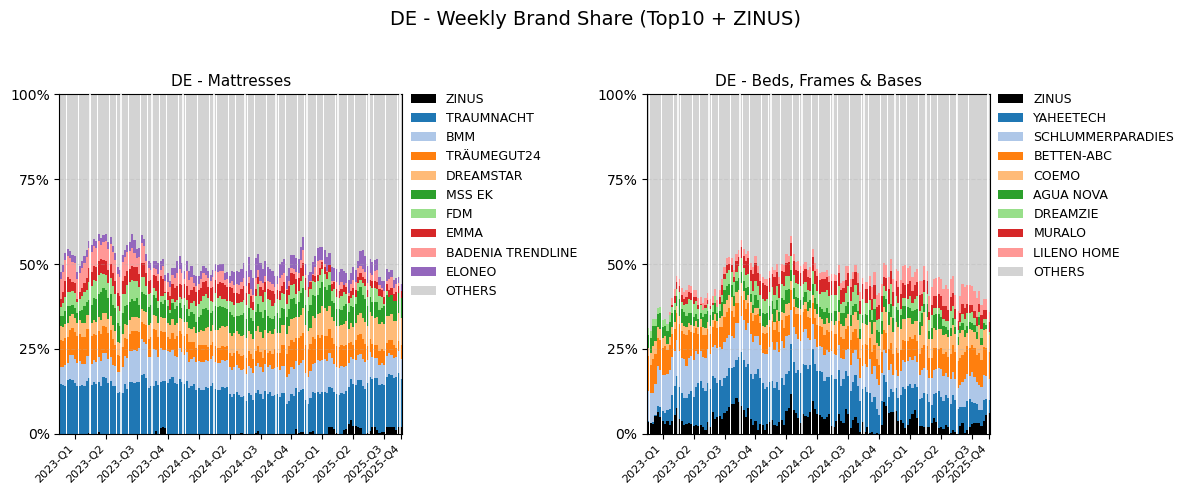

In [71]:
# ---- Helper: 분기 라벨 & 경계 ----
def quarter_label_from_week(wlabel):
    y, wk = parse_yrweek(wlabel)
    q = (wk - 1)//13 + 1
    return f"{y}-Q{q}"

def quarter_bounds_from_weeks(weeks):
    qlabs = [quarter_label_from_week(w) for w in weeks]
    bounds, s = [], 0
    for i in range(1, len(qlabs)):
        if qlabs[i] != qlabs[i-1]:
            bounds.append((s, i-1, qlabs[i-1]))
            s = i
    if qlabs:
        bounds.append((s, len(qlabs)-1, qlabs[-1]))
    return bounds


# ---- 국가별 Figure ----
countries = ['UK','IT','FR','ES','DE']
for country in countries:
    sub_country = comp[comp['country'] == country].copy()
    if sub_country.empty:
        continue

    # ✅ 카테고리: 'Mattress' 포함 우선 + 나머지는 알파벳순
    cats = list(sub_country['bsr_ctgry'].unique())
    cats = sorted(cats, key=lambda c: (0 if 'mattress' in c.lower() else 1, c.lower()))

    ncols = 2
    nrows = math.ceil(len(cats)/ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)
    fig.suptitle(f"{country} - Weekly Brand Share (Top10 + ZINUS)", fontsize=14, y=0.98)

    for i, cat in enumerate(cats):
        ax  = axes[i//ncols, i%ncols]
        sub = sub_country[sub_country['bsr_ctgry'] == cat].copy()
        if sub.empty:
            ax.axis('off'); continue

        # --- 주차 정렬 & pivot ---
        weeks = sorted(sub['yr_week'].unique(), key=parse_yrweek)
        pivot = (sub.pivot_table(index='yr_week', columns='brand_compact',
                                 values='brand_share', aggfunc='sum')
                   .reindex(index=weeks).fillna(0.0))

        for req in ('ZINUS','OTHERS'):
            if req not in pivot.columns:
                pivot[req] = 0.0

        # --- 스택 순서 ---
        rest = [c for c in pivot.columns if c not in ('ZINUS','OTHERS')]
        rest_sorted = pivot[rest].sum(0).sort_values(ascending=False).index.tolist()
        pivot = pivot[['ZINUS', *rest_sorted, 'OTHERS']]

        # --- 100% 정규화 ---
        pivot = pivot.div(pivot.sum(axis=1).replace(0, 1), axis=0)

        # --- 색상 ---
        base_colors = plt.cm.tab20.colors
        color_map = {'ZINUS':'black','OTHERS':'lightgray'}
        for j, br in enumerate(rest_sorted):
            color_map[br] = base_colors[j % len(base_colors)]

        # --- 막대 ---
        x = np.arange(len(pivot))
        bottom = np.zeros(len(pivot))
        for col in pivot.columns:
            ax.bar(x, pivot[col].values, bottom=bottom, width=0.9,
                   label=(col if len(col) <= 20 else col[:20]),
                   color=color_map[col])
            bottom += pivot[col].values

        # --- Y축 ---
        ax.set_ylim(0, 1)
        ax.set_yticks([0,.25,.5,.75,1.0])
        ax.set_yticklabels(['0%','25%','50%','75%','100%'])
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.set_xlim(-0.5, len(x)-0.5)

        # ✅ 타이틀: 국가 + 카테고리
        ax.set_title(f"{country} - {cat}", fontsize=11)

        # --- X축: 분기 라벨 & 구분선 ---
        qbounds = quarter_bounds_from_weeks(weeks)
        ax.set_xticks([(s+e)/2 for s,e,_ in qbounds])
        ax.set_xticklabels([lbl for _,_,lbl in qbounds], rotation=45, ha='right', fontsize=8)
        for s, e, _ in qbounds[:-1]:
            ax.axvline(e+0.5, color='white', linewidth=1.2, zorder=3)

        # --- 범례 ---
        ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.02),
                  borderaxespad=0., fontsize=9, frameon=False)

    # 빈축 제거
    for j in range(i+1, nrows*ncols):
        axes[j//ncols, j%ncols].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [90]:
df3 = df.copy()
df_es = df3[df3['country']=='ES']

In [91]:
df_es.groupby('bsr_ctgry').count()

,country,asin,rank,bsr_date,brand,title,image_url,bsr_ctgry_label,pdt_url,yr_month,yr_week,is_maxdt,is_maxdt_range,bsr_ord,brand_prod_num,brand_ord,date_str,bsr_rank_range,brand_legend_ord
bsr_ctgry,,,,,,,,,,,,,,,,,,,
Beds,77888,77888,77888,77888,77888,77882,77882,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888
"Beds, frames and bases",77897,77897,77897,77897,77897,77895,77895,77897,77897,77897,77897,77897,77897,77897,77897,77897,77897,77897,77897
"Beds, structures and bases",77915,77915,77915,77915,77915,77913,77913,77915,77915,77915,77915,77915,77915,77915,77915,77915,77915,77915,77915
Chairs,77887,77887,77887,77887,77887,77885,77885,77887,77887,77887,77887,77887,77887,77887,77887,77887,77887,77887,77887
bed bases,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888
desks,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900
frames,77890,77890,77890,77890,77890,77883,77883,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890
mattresses,77918,77918,77918,77918,77918,77914,77914,77918,77918,77918,77918,77918,77918,77918,77918,77918,77918,77918,77918
slatted bed bases,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890
